# Numerical Analysis for Machine Learning
## PageRank Algorithm

**Academic Year:** 2025/2026  
**Professor:** Edie Miglio  
**Author:** Riccardo Infascelli (Codice Persona: 10742969, Matricola: 259426)

This notebook contains the Python implementation and the numerical experiments developed for the PageRank project. The mathematical formulation of the algorithm is discussed in the accompanying report.

The analysis starts from a basic implementation, then considers sparse matrices, convergence with respect to the damping factor, and applications to real networks.

In [131]:
import re
import time
from pathlib import Path
import tarfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx

from scipy.sparse import csr_matrix
from scipy.stats import spearmanr

SEED = 0
rng = np.random.default_rng(SEED)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

## Basic PageRank implementation

We first implement PageRank directly from the iterative update formula.  
The graph is represented by a list of directed edges, where `(i, j)` means that node `i` links to node `j`.

At each iteration, the rank received through incoming links is combined with the rank redistributed from dangling nodes and with the teleportation term:

$$
x_i^{(k+1)}
=
\frac{1-\alpha}{n}
+
\alpha
\left(
\sum_{j \to i}
\frac{x_j^{(k)}}{\operatorname{outdeg}(j)}
+
\frac{\mathrm{sink\_mass}}{n}
\right).
$$

The iteration stops when the $L^1$ residual between two consecutive vectors is smaller than the prescribed tolerance.

In [132]:
def pagerank_basic(n, edges, alpha=0.85, max_iter=1000, tol=1e-8):
    backlinks = [[] for _ in range(n)]
    out_degree = np.zeros(n, dtype=int)

    for i, j in edges:
        backlinks[j].append(i)
        out_degree[i] += 1

    rank = np.ones(n) / n
    residuals = []

    for _ in range(max_iter):
        sink_mass = rank[out_degree == 0].sum()

        new_rank = np.full(
            n,
            (1 - alpha) / n + alpha * sink_mass / n
        )

        for i in range(n):
            for j in backlinks[i]:
                new_rank[i] += alpha * rank[j] / out_degree[j]

        residual = np.linalg.norm(new_rank - rank, 1)
        residuals.append(residual)

        rank = new_rank

        if residual < tol:
            break

    return rank, residuals

## A first example from the literature

We first test the implementation on a six-page graph taken from Langville and Meyer. The graph includes a dangling node, making it a useful example for checking the complete PageRank update.


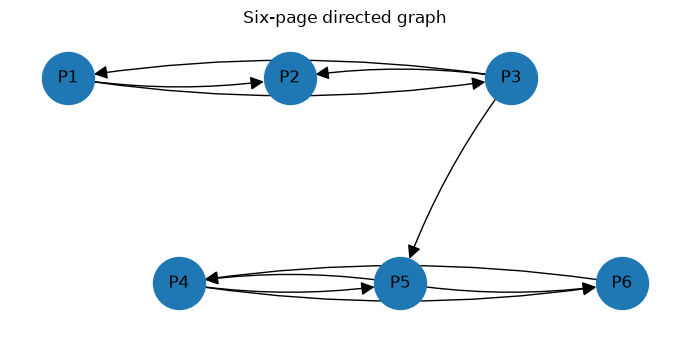

In [133]:
n = 6

edges = [
    (0, 1), (0, 2),
    (2, 0), (2, 1), (2, 4),
    (3, 4), (3, 5),
    (4, 3), (4, 5),
    (5, 3),
]

graph_example = nx.DiGraph()
graph_example.add_nodes_from(range(n))
graph_example.add_edges_from(edges)

positions = {
    0: (0.0, 1.0),
    1: (1.0, 1.0),
    2: (2.0, 1.0),
    3: (0.5, 0.0),
    4: (1.5, 0.0),
    5: (2.5, 0.0),
}

labels = {node: f"P{node + 1}" for node in graph_example.nodes}

plt.figure(figsize=(7, 3.5))

nx.draw_networkx(
    graph_example,
    pos=positions,
    labels=labels,
    node_size=1400,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.08",
)

plt.title("Six-page directed graph")
plt.axis("off")
plt.tight_layout()
plt.show()

In [134]:
rank_book, residuals_book = pagerank_basic(n, edges)

print("PageRank:", rank_book)
print("Sum:", rank_book.sum())
print("Iterations:", len(residuals_book))

PageRank: [0.05170475 0.07367926 0.05741241 0.34870368 0.19990381 0.26859608]
Sum: 1.0
Iterations: 33


To validate the result, we compare the iterative solution with the eigenvector of the Google matrix associated with the eigenvalue \(1\). Since the graph is very small, the matrix can be built explicitly for this test.

In [135]:
def google_matrix(n, edges, alpha=0.85):
    H = np.zeros((n, n))
    out_degree = np.zeros(n, dtype=int)

    for i, j in edges:
        out_degree[i] += 1

    for i, j in edges:
        H[i, j] = 1 / out_degree[i]

    H[out_degree == 0, :] = 1 / n

    return alpha * H + (1 - alpha) * np.ones((n, n)) / n


G = google_matrix(n, edges)

eigenvalues, eigenvectors = np.linalg.eig(G.T)
idx = np.argmin(np.abs(eigenvalues - 1))

rank_eig = np.real(eigenvectors[:, idx])
rank_eig /= rank_eig.sum()

print("Power iteration:", rank_book)
print("Eigensolver:    ", rank_eig)
print("L1 difference:  ", np.linalg.norm(rank_book - rank_eig, 1))

Power iteration: [0.05170475 0.07367926 0.05741241 0.34870368 0.19990381 0.26859608]
Eigensolver:     [0.05170475 0.07367926 0.05741241 0.34870369 0.19990381 0.26859608]
L1 difference:   8.537085829929403e-09


The power iteration and the direct eigensolver give the same PageRank vector up to the prescribed tolerance. The $L^1$ difference is approximately $8.5 \times 10^{-9}$, confirming the correctness of the implementation on this example.

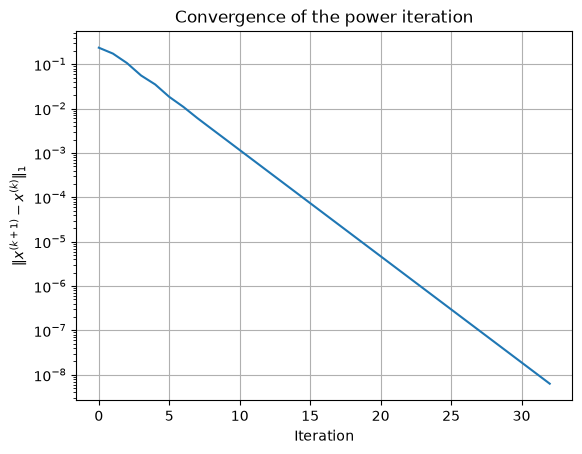

In [136]:
plt.semilogy(residuals_book)
plt.xlabel("Iteration")
plt.ylabel(r"$\|x^{(k+1)}-x^{(k)}\|_1$")
plt.title("Convergence of the power iteration")
plt.grid(True)
plt.show()

After a short initial phase, the residual decreases almost linearly on the logarithmic scale, showing the expected geometric convergence of the power iteration.

## Effect of the damping factor

We repeat the computation for different values of $\alpha$. A larger value gives more weight to the link structure and less to teleportation, but it is also expected to slow down the convergence.

In [137]:
alpha_values = [0.10, 0.50, 0.85, 0.95, 0.99]

rows = []
ranks_alpha = {}

for alpha in alpha_values:
    rank, residuals = pagerank_basic(n, edges, alpha=alpha)

    ranks_alpha[alpha] = rank

    rows.append({
        "alpha": alpha,
        "iterations": len(residuals),
        "final residual": residuals[-1]
    })

damping_results = pd.DataFrame(rows)
damping_results

,alpha,iterations,final residual
0,0.10,7,3.409946e-09
1,0.50,17,5.142719e-09
2,0.85,33,6.279296e-09
3,0.95,41,7.293612e-09
4,0.99,45,8.025144e-09


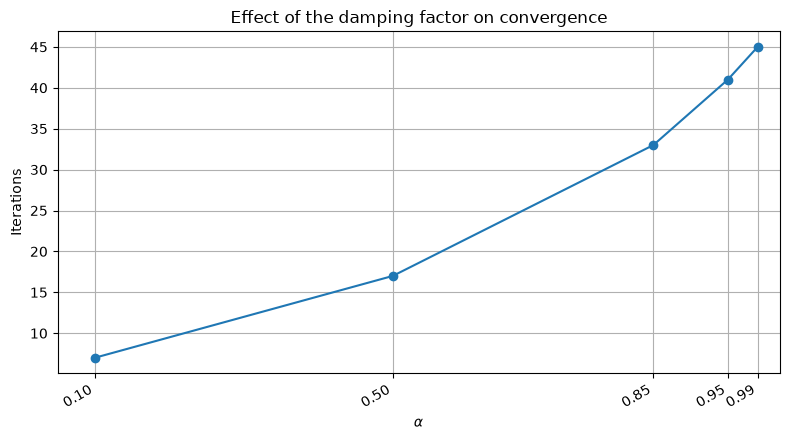

In [138]:
plt.figure(figsize=(8, 4.5))

plt.plot(
    damping_results["alpha"],
    damping_results["iterations"],
    marker="o"
)

plt.xlabel(r"$\alpha$")
plt.ylabel("Iterations")
plt.title("Effect of the damping factor on convergence")

plt.xticks(
    alpha_values,
    [f"{alpha:.2f}" for alpha in alpha_values],
    rotation=30,
    ha="right"
)

plt.xlim(0.05, 1.02)
plt.grid(True)
plt.tight_layout()
plt.show()

The number of iterations increases with $\alpha$. When teleportation is reduced, the convergence becomes more dependent on the link structure of the graph and is generally slower. In this example, the number of iterations increases from 7 for $\alpha=0.10$ to 45 for $\alpha=0.99$.

In [139]:
rank_comparison = pd.DataFrame(
    {f"alpha={alpha}": ranks_alpha[alpha] for alpha in alpha_values},
    index=[f"P{i}" for i in range(1, n + 1)]
)

rank_comparison

,alpha=0.1,alpha=0.5,alpha=0.85,alpha=0.95,alpha=0.99
P1,0.158123,0.116183,0.051705,0.020241,0.004359
P2,0.166029,0.145228,0.073679,0.029855,0.006516
P3,0.160673,0.124481,0.057412,0.022675,0.004899
P4,0.178121,0.239004,0.348704,0.406464,0.436222
P5,0.167029,0.175934,0.199904,0.213311,0.220289
P6,0.170025,0.199170,0.268596,0.307454,0.327715


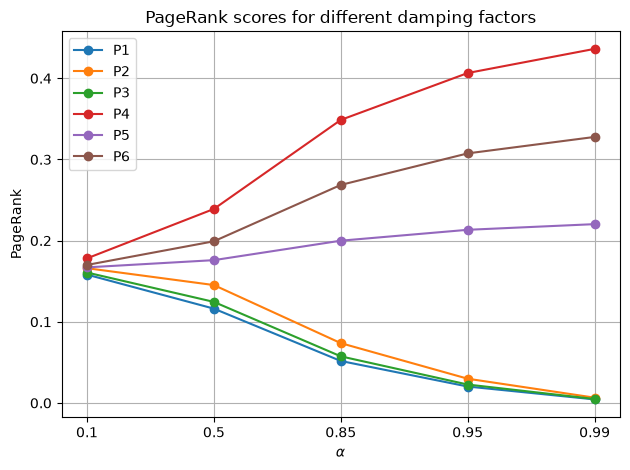

In [140]:
x = np.arange(len(alpha_values))

for page in rank_comparison.index:
    plt.plot(
        x,
        rank_comparison.loc[page],
        marker="o",
        label=page
    )

plt.xlabel(r"$\alpha$")
plt.ylabel("PageRank")
plt.title("PageRank scores for different damping factors")
plt.xticks(x, alpha_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The ordering of the pages remains unchanged for all the tested values of $\alpha$, but the PageRank scores become increasingly concentrated. For small $\alpha$, teleportation keeps the distribution close to uniform. As $\alpha$ approaches one, most of the rank accumulates in pages 4, 5 and 6, which form a closed group receiving an incoming link from the upper part of the graph.

## Sparse implementation

The basic implementation works well for small graphs, but the Python loops become expensive when the number of edges increases. We therefore store the hyperlink matrix in sparse format and use matrix-vector products.

In [141]:
def build_sparse_matrix(n, edges):
    rows = np.array([i for i, j in edges])
    cols = np.array([j for i, j in edges])

    out_degree = np.bincount(rows, minlength=n)
    data = 1 / out_degree[rows]

    H = csr_matrix((data, (rows, cols)), shape=(n, n))
    dangling = out_degree == 0

    return H, dangling

In [142]:
def pagerank_sparse(H, dangling, alpha=0.85, max_iter=1000, tol=1e-8):
    n = H.shape[0]
    rank = np.ones(n) / n
    residuals = []

    for _ in range(max_iter):
        sink_mass = rank[dangling].sum()

        new_rank = (
            alpha * (H.T @ rank)
            + (alpha * sink_mass + 1 - alpha) / n
        )

        residual = np.linalg.norm(new_rank - rank, 1)
        residuals.append(residual)

        rank = new_rank

        if residual < tol:
            break

    return rank, residuals

In [143]:
H, dangling = build_sparse_matrix(n, edges)

rank_sparse, residuals_sparse = pagerank_sparse(H, dangling)

print("Basic implementation:", rank_book)
print("Sparse implementation:", rank_sparse)
print("L1 difference:", np.linalg.norm(rank_book - rank_sparse, 1))
print("Iterations:", len(residuals_sparse))

Basic implementation: [0.05170475 0.07367926 0.05741241 0.34870368 0.19990381 0.26859608]
Sparse implementation: [0.05170475 0.07367926 0.05741241 0.34870368 0.19990381 0.26859608]
L1 difference: 1.5265566588595902e-16
Iterations: 33


The basic and sparse implementations produce the same PageRank vector. The difference is at machine precision, confirming that the sparse formulation preserves the original iteration.

In [144]:
def random_graph(n, avg_degree=10):
    edges = []

    for i in range(n):
        targets = rng.choice(n, size=avg_degree, replace=False)
        edges.extend((i, int(j)) for j in targets if j != i)

    return edges

In [145]:
sizes = [100, 500, 1000, 5000]
repetitions = 5
rows = []

for n_test in sizes:
    edges_test = random_graph(n_test)

    basic_times = []
    sparse_times = []

    for _ in range(repetitions):
        start = time.perf_counter()
        rank_basic_test, _ = pagerank_basic(n_test, edges_test)
        basic_times.append(time.perf_counter() - start)

        start = time.perf_counter()
        H_test, dangling_test = build_sparse_matrix(n_test, edges_test)
        rank_sparse_test, _ = pagerank_sparse(H_test, dangling_test)
        sparse_times.append(time.perf_counter() - start)

    basic_time = np.median(basic_times)
    sparse_time = np.median(sparse_times)

    rows.append({
        "nodes": n_test,
        "edges": len(edges_test),
        "basic time": basic_time,
        "sparse time": sparse_time,
        "speedup": basic_time / sparse_time,
        "L1 difference": np.linalg.norm(
            rank_basic_test - rank_sparse_test, 1
        )
    })

performance_results = pd.DataFrame(rows)
performance_results

,nodes,edges,basic time,sparse time,speedup,L1 difference
0,100,990,0.003255,0.000390,8.343115,9.627715e-17
1,500,4995,0.017008,0.000742,22.916113,1.768334e-16
2,1000,9987,0.033567,0.001212,27.688518,1.759118e-16
3,5000,49983,0.166977,0.004986,33.487866,2.053343e-16


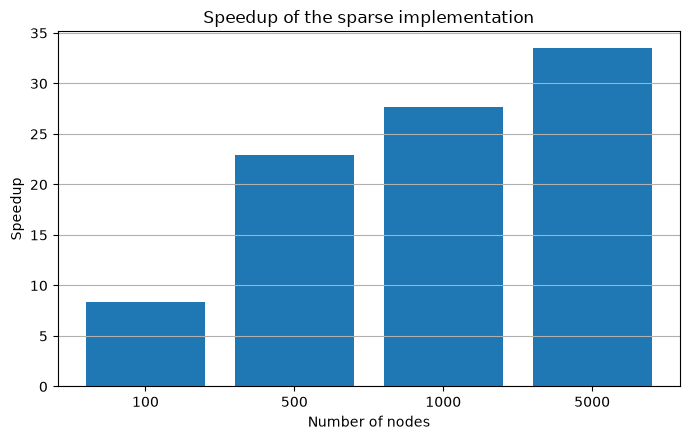

In [ ]:
labels = performance_results["nodes"].astype(str)

plt.figure(figsize=(7, 4.5))

plt.bar(
    labels,
    performance_results["speedup"]
)

plt.xlabel("Number of nodes")
plt.ylabel("Speedup")
plt.title("Speedup of the sparse implementation")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

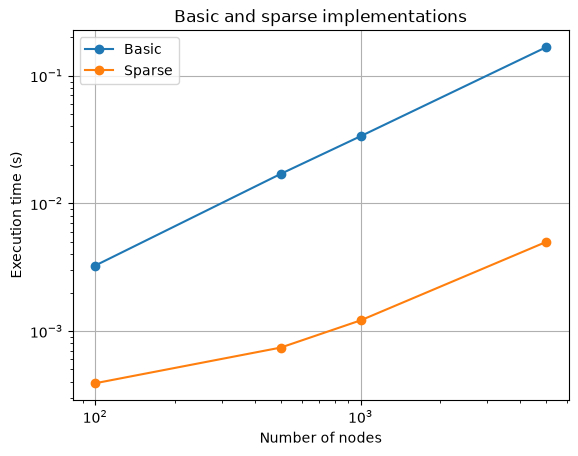

In [147]:
plt.loglog(
    performance_results["nodes"],
    performance_results["basic time"],
    marker="o",
    label="Basic"
)

plt.loglog(
    performance_results["nodes"],
    performance_results["sparse time"],
    marker="o",
    label="Sparse"
)

plt.xlabel("Number of nodes")
plt.ylabel("Execution time (s)")
plt.title("Basic and sparse implementations")
plt.legend()
plt.grid(True)
plt.show()

The sparse implementation is consistently faster than the basic version, and the difference becomes more evident as the graph size increases. Both methods still produce the same PageRank vector up to machine precision.

## Linear system formulation

The PageRank vector can also be obtained by solving

$$
(I-\alpha S^T)x=(1-\alpha)v,
$$

where $S$ is the stochastic hyperlink matrix and $v$ is the uniform teleportation vector. On this small example, we compare the solution of the linear system with the result of the power iteration.

In [148]:
alpha = 0.85
v = np.ones(n) / n

S = H.toarray()
S[dangling, :] = 1 / n

A = np.eye(n) - alpha * S.T
b = (1 - alpha) * v

rank_linear = np.linalg.solve(A, b)
rank_linear /= rank_linear.sum()

print("Power iteration:", rank_sparse)
print("Linear system:  ", rank_linear)
print("L1 difference:  ", np.linalg.norm(rank_sparse - rank_linear, 1))

Power iteration: [0.05170475 0.07367926 0.05741241 0.34870368 0.19990381 0.26859608]
Linear system:   [0.05170475 0.07367926 0.05741241 0.34870369 0.19990381 0.26859608]
L1 difference:   8.537085226245633e-09


The linear system gives the same PageRank vector as the power iteration. The $L^1$ difference is approximately $8.5 \times 10^{-9}$, consistently with the stopping tolerance.

## Finding scientific gems

This experiment is inspired by the paper *Finding Scientific Gems with Google's PageRank Algorithm* by Chen, Xie, Maslov and Redner. The idea is to compare PageRank with the number of citations received by each paper.

In [149]:
EDGE_FILE = DATA_DIR / "cit-HepTh.txt.gz"

if not EDGE_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found: {EDGE_FILE}"
    )

edge_data = pd.read_csv(
    EDGE_FILE,
    sep=r"\s+",
    comment="#",
    names=["source", "target"],
    compression="gzip",
)

edge_data.head()

,source,target
0,1001,9304045
1,1001,9308122
2,1001,9309097
3,1001,9311042
4,1001,9401139


In [150]:
edge_data = (
    edge_data
    .drop_duplicates()
    .query("source != target")
    .reset_index(drop=True)
)

print("Number of citations:", len(edge_data))
edge_data.head()

Number of citations: 352768


,source,target
0,1001,9304045
1,1001,9308122
2,1001,9309097
3,1001,9311042
4,1001,9401139


In [151]:
node_ids = np.union1d(
    edge_data["source"].to_numpy(),
    edge_data["target"].to_numpy()
)

print("Number of papers:", len(node_ids))
print("Number of citations:", len(edge_data))

Number of papers: 27769
Number of citations: 352768


In [152]:
node_to_idx = {
    node_id: idx for idx, node_id in enumerate(node_ids)
}

sources = edge_data["source"].map(node_to_idx).to_numpy()
targets = edge_data["target"].map(node_to_idx).to_numpy()

n_nodes = len(node_ids)

In [153]:
out_degree = np.bincount(sources, minlength=n_nodes)
data = 1.0 / out_degree[sources]

H_cit = csr_matrix(
    (data, (sources, targets)),
    shape=(n_nodes, n_nodes)
)

dangling_cit = out_degree == 0

print("Dangling nodes:", dangling_cit.sum())

Dangling nodes: 2714


In [154]:
rank_cit, residuals_cit = pagerank_sparse(
    H_cit,
    dangling_cit,
    alpha=0.5,
    tol=1e-8
)

print("Sum:", rank_cit.sum())
print("Iterations:", len(residuals_cit))
print("Final residual:", residuals_cit[-1])

Sum: 1.0
Iterations: 20
Final residual: 5.590371530139613e-09


The PageRank vector is normalized and the iteration converges in 20 steps. We now compare PageRank with the number of citations received by each paper.

In [155]:
citation_count = np.bincount(targets, minlength=n_nodes)

results = pd.DataFrame({
    "paper_id": node_ids,
    "pagerank": rank_cit,
    "citations": citation_count
})

results["pagerank_rank"] = (
    results["pagerank"]
    .rank(method="min", ascending=False)
    .astype(int)
)

results["citation_rank"] = (
    results["citations"]
    .rank(method="min", ascending=False)
    .astype(int)
)

results["rank_ratio"] = (
    results["citation_rank"] / results["pagerank_rank"]
)

results.sort_values("pagerank_rank").head(10)

,paper_id,pagerank,citations,pagerank_rank,citation_rank,rank_ratio
14158,9407087,0.002686,1299,1,4,4.000000
22152,9711200,0.002301,2414,2,1,0.500000
16725,9510017,0.001766,1155,3,6,2.000000
15602,9503124,0.001725,1114,4,8,2.000000
14349,9408099,0.001589,1006,5,10,2.000000
22742,9802150,0.001559,1775,6,2,0.333333
19154,9610043,0.001477,1199,7,5,0.714286
22708,9802109,0.001396,1641,8,3,0.375000
26166,9906064,0.001247,1032,9,9,1.000000
14723,9410167,0.001175,748,10,15,1.500000


In [156]:
rho, _ = spearmanr(
    results["pagerank"],
    results["citations"]
)

print("Spearman correlation:", rho)

Spearman correlation: 0.867897884452234


The Spearman correlation between PageRank and citation count is approximately $0.868$. The two rankings are therefore strongly related, although the correlation is not perfect. The differences between them may reveal papers whose importance is better captured by the citation network than by citation count alone.

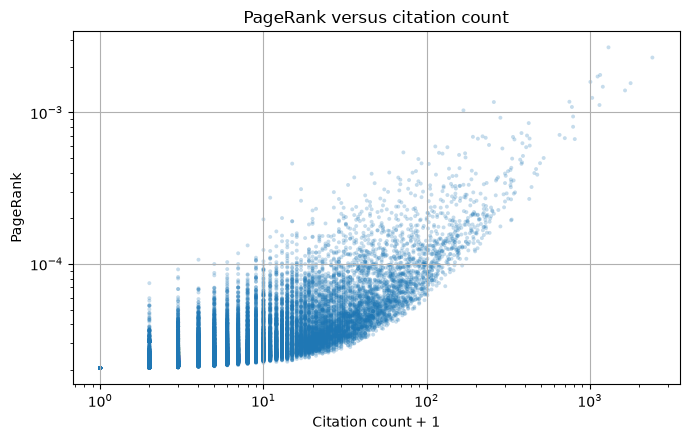

In [ ]:
plt.figure(figsize=(7, 4.5))

plt.scatter(
    results["citations"] + 1,
    results["pagerank"],
    s=8,
    alpha=0.25,
    edgecolors="none"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Citation count + 1")
plt.ylabel("PageRank")
plt.title("PageRank versus citation count")

plt.grid(True, which="major")
plt.tight_layout()
plt.show()

The log-log scatter plot shows a clear positive association between PageRank and citation count. However, the dispersion indicates that papers with a similar number of citations can receive different PageRank scores, since the importance of the citing papers also matters.


## Top papers by PageRank

We first inspect the ten papers with the highest PageRank and compare their position with the ranking based on citation count.

In [158]:
top10_pagerank = (
    results
    .sort_values("pagerank_rank")
    .head(10)
    [[
        "paper_id",
        "pagerank",
        "pagerank_rank",
        "citations",
        "citation_rank",
        "rank_ratio"
    ]]
    .reset_index(drop=True)
)

top10_pagerank

,paper_id,pagerank,pagerank_rank,citations,citation_rank,rank_ratio
0,9407087,0.002686,1,1299,4,4.000000
1,9711200,0.002301,2,2414,1,0.500000
2,9510017,0.001766,3,1155,6,2.000000
3,9503124,0.001725,4,1114,8,2.000000
4,9408099,0.001589,5,1006,10,2.000000
5,9802150,0.001559,6,1775,2,0.333333
6,9610043,0.001477,7,1199,5,0.714286
7,9802109,0.001396,8,1641,3,0.375000
8,9906064,0.001247,9,1032,9,1.000000
9,9410167,0.001175,10,748,15,1.500000


The highest-ranked papers by PageRank also occupy high positions in the citation ranking. The two measures therefore largely agree at the top of the network, although the exact ordering is different.

In [159]:
gems = (
    results[
        (results["pagerank_rank"] <= 100)
        & (results["rank_ratio"] > 10)
    ]
    .sort_values("rank_ratio", ascending=False)
    [[
        "paper_id",
        "pagerank",
        "pagerank_rank",
        "citations",
        "citation_rank",
        "rank_ratio"
    ]]
    .reset_index(drop=True)
)

print("Number of candidate gems:", len(gems))
gems

Number of candidate gems: 13


,paper_id,pagerank,pagerank_rank,citations,citation_rank,rank_ratio
0,9201015,0.000459,52,14,5722,110.038462
1,9206047,0.000372,75,35,2187,29.160000
2,9208055,0.000332,97,32,2429,25.041237
3,9205037,0.000394,68,45,1546,22.735294
4,9204102,0.000544,38,71,781,20.552632
5,9402005,0.000401,63,58,1090,17.301587
6,9201059,0.000341,89,47,1450,16.292135
7,9205068,0.001031,14,167,174,12.428571
8,9202057,0.000492,47,88,558,11.872340
9,9206007,0.000371,76,66,890,11.710526


Among the first 100 papers by PageRank, 13 have a citation rank more than ten times worse than their PageRank rank. The most extreme case is paper 9201015, which is ranked 52nd by PageRank but only 5722nd by citation count. These papers can be considered candidate scientific gems, since their position in the citation network appears much more important than their raw number of citations suggests.

In [160]:
METADATA_ARCHIVE = DATA_DIR / "cit-HepTh-abstracts.tar.gz"
METADATA_DIR = DATA_DIR / "hepth_metadata"

if not METADATA_ARCHIVE.exists():
    raise FileNotFoundError(
        f"Metadata archive not found: {METADATA_ARCHIVE}"
    )

METADATA_DIR.mkdir(exist_ok=True)

metadata_files = list(METADATA_DIR.rglob("*.abs"))

if not metadata_files:
    with tarfile.open(METADATA_ARCHIVE, "r:gz") as archive:
        archive.extractall(METADATA_DIR, filter="data")

    metadata_files = list(METADATA_DIR.rglob("*.abs"))

print("Metadata files:", len(metadata_files))

Metadata files: 29555


In [161]:
def parse_abs_file(path):
    lines = path.read_text(
        encoding="latin-1",
        errors="replace"
    ).splitlines()

    separators = [
        i for i, line in enumerate(lines)
        if line.strip() == r"\\"
    ]

    header_lines = lines[separators[0] + 1:separators[1]]

    fields = {}
    current_field = None

    for line in header_lines:
        match = re.match(
            r"^([A-Za-z][A-Za-z-]*):\s*(.*)$",
            line
        )

        if match:
            current_field = match.group(1).lower()
            fields[current_field] = match.group(2).strip()

        elif current_field is not None and line.strip():
            fields[current_field] += " " + line.strip()

    paper_match = re.search(
        r"(\d{7})",
        fields.get("paper", path.stem)
    )

    return {
        "paper_id": int(paper_match.group(1)),
        "title": fields.get("title"),
        "authors": fields.get("authors"),
        "date": fields.get("date"),
        "journal_ref": fields.get("journal-ref")
    }

In [162]:
records = [
    parse_abs_file(path)
    for path in metadata_files
]

metadata = (
    pd.DataFrame(records)
    .drop_duplicates("paper_id")
    .reset_index(drop=True)
)

print("Metadata records:", len(metadata))
print("Missing titles:", metadata["title"].isna().sum())

metadata.head()

Metadata records: 29555
Missing titles: 0


,paper_id,title,authors,date,journal_ref
0,9301112,On Integrable c<1 Open--Closed String Theory,Clifford V. Johnson,"Tue, 26 Jan 93 23:02:22 EST (24kb) Date (revised): Fri, 18 Jun 93 10:29:13 EDT",Nucl.Phys. B414 (1994) 239-266
1,9303063,Schwinger Effect in String Theory,C.Bachas,"Wed, 10 Mar 1993 14:07:49 +0100 (5kb) Date (revised): Tue, 16 Mar 1993 12:23:42 +0100",NaN
2,9308136,Proof of Jacobi identity in generalized quantum dynamics,"S.L. Adler, G.V. Bhanot, J.D. Weckel",27 Aug 1993 15:19:57 -0400 (EDT) (6kb),J.Math.Phys. 35 (1994) 531-535
3,9308122,"Mirror Symmetry, Mirror Map and Applications to Calabi-Yau Hypersurfaces","S. Hosono, A. Klemm, S. Theisen","Thu, 26 Aug 93 14:09:47 SET (52kb) Date (revised): Fri, 12 Nov 93 20:42:07 SET",Commun.Math.Phys. 167 (1995) 301-350
4,9303077,Abelian Anomalies in Nonlocal Regularization,"M. A. Clayton, L. Demopoulos, J. W. Moffat","Fri, 12 Mar 1993 11:43:32 -0500 (12kb)",Int. Journ. Mod. Phys. A9 (1994) Pg. 4549-4564


In [163]:
gems_with_metadata = gems.merge(
    metadata,
    on="paper_id",
    how="left"
)

pd.set_option("display.max_colwidth", 120)

gems_with_metadata[[
    "paper_id",
    "title",
    "authors",
    "pagerank_rank",
    "citations",
    "citation_rank",
    "rank_ratio"
]]

,paper_id,title,authors,pagerank_rank,citations,citation_rank,rank_ratio
0,9201015,An Algorithm to Generate Classical Solutions for String Effective Action,"S. Kar, S. Khastgir and A. Kumar",52,14,5722,110.038462
1,9206047,Addendum to ``Integrability of Open Spin Chains with Quantum Algebra Symmetry'',Luca Mezincescu and Rafael I. Nepomechie,75,35,2187,29.160000
2,9208055,Putting String/Fivebrane Duality to the Test,"J. A. Dixon, M. J. Duff and J. C. Plefka",97,32,2429,25.041237
3,9205037,Global Analysis of New Gravitational Singularities in String and Particle Theories,I. Bars and K. Sfetsos (USC),68,45,1546,22.735294
4,9204102,A New Supersymmetric Index,"Sergio Cecotti, Paul Fendley, Ken Intriligator and Cumrun Vafa",38,71,781,20.552632
5,9402005,Field Dependent Gauge Couplings in Locally Supersymmetric Effective Quantum Field Theories,V.Kaplunovsky and J.Louis,63,58,1090,17.301587
6,9201059,Quantum Hair on Black Holes,"Sidney Coleman, John Preskill, and Frank Wilczek",89,47,1450,16.292135
7,9205068,"ERRATA for ""One-Loop Threshold Effects in String Unification""",Vadim Kaplunovsky,14,167,174,12.428571
8,9202057,Exchange Operator Formalism for Integrable Systems of Particles,Alexios P. Polychronakos,47,88,558,11.872340
9,9206007,Chern-Simons Theory as the Large Mass Limit of Topologically Massive Yang-Mills Theory,"G. Giavarini, C.P. Martin, F. Ruiz Ruiz",76,66,890,11.710526


The analysis identifies 13 candidate scientific gems among the first 100 papers by PageRank. The strongest discrepancy is observed for *An Algorithm to Generate Classical Solutions for String Effective Action*, which is ranked 52nd by PageRank but only 5722nd by citation count.

These results show that PageRank can identify papers that occupy an important position in the citation network despite having relatively few citations. However, the presence of errata and addenda among the candidates also shows that a high structural importance does not necessarily imply a major scientific contribution. The selected papers should therefore be interpreted as candidates requiring further qualitative evaluation.

## Influence of publication year

We examine whether publication year affects PageRank. Older papers may have an advantage because they have had more time to accumulate citations and become connected to later influential work.

In [164]:
year_data = results.copy()

paper_code = (
    year_data["paper_id"]
    .astype(str)
    .str.zfill(7)
)

yy = paper_code.str[:2].astype(int)

year_data["year"] = np.where(
    yy >= 90,
    1900 + yy,
    2000 + yy
)

year_summary = (
    year_data
    .groupby("year")
    .agg(
        average_pagerank=("pagerank", "mean"),
        median_pagerank=("pagerank", "median"),
        publications=("paper_id", "size")
    )
    .reset_index()
)

year_summary

,year,average_pagerank,median_pagerank,publications
0,1992,0.000072,0.000045,1120
1,1993,0.000048,0.000031,1721
2,1994,0.000045,0.000028,2083
3,1995,0.000046,0.000029,2154
4,1996,0.000041,0.000028,2463
5,1997,0.000037,0.000027,2583
6,1998,0.000035,0.000026,2642
7,1999,0.000033,0.000025,2719
8,2000,0.000029,0.000025,3038
9,2001,0.000026,0.000023,3064


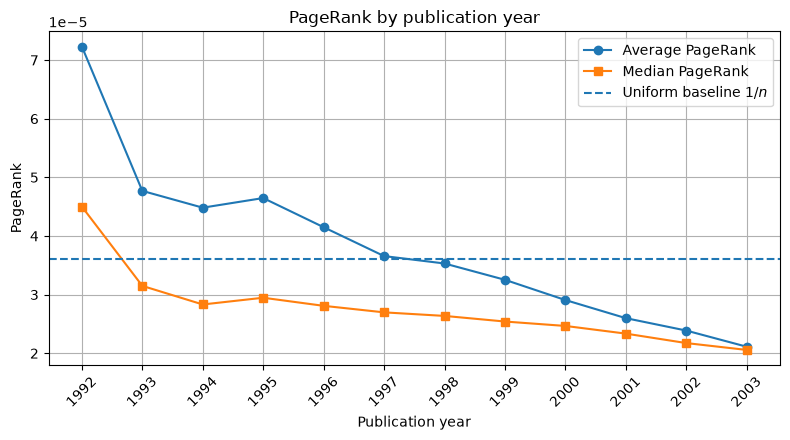

In [ ]:
uniform_pagerank = 1 / len(year_data)

plt.figure(figsize=(8, 4.5))

plt.plot(
    year_summary["year"],
    year_summary["average_pagerank"],
    marker="o",
    label="Average PageRank"
)

plt.plot(
    year_summary["year"],
    year_summary["median_pagerank"],
    marker="s",
    label="Median PageRank"
)

plt.axhline(
    uniform_pagerank,
    linestyle="--",
    label=r"Uniform baseline $1/n$"
)

plt.xlabel("Publication year")
plt.ylabel("PageRank")
plt.title("PageRank by publication year")

plt.xticks(year_summary["year"], rotation=45)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

The average and median PageRank decrease with publication year, suggesting
an age advantage for older papers. These papers have had more time to
accumulate citations and to become connected to later influential works.
However, this trend should not be interpreted as an intrinsic bias of
PageRank, since it is also affected by the finite observation window of
the dataset, especially for the partially observed year 2003.

In [166]:
rho_year, p_year = spearmanr(
    year_data["year"],
    year_data["pagerank"]
)

print("Spearman correlation:", rho_year)
print("p-value:", p_year)

Spearman correlation: -0.3947554490626973
p-value: 0.0


The Spearman correlation between publication year and PageRank is
\(\rho_S=-0.395\), with \(p<10^{-16}\). This confirms a statistically
significant moderate negative association: more recent papers tend to
receive lower PageRank scores. The result is consistent with an age
advantage, but it does not establish an intrinsic bias of PageRank,
since older papers have had a longer citation window and the most
recent years are only partially observed.

## Sensitivity to the damping factor

We repeat the PageRank computation on the HEP-TH network for different values of $\alpha$. The ranking obtained with $\alpha=0.50$ is used as the reference for the Spearman correlations.

In [167]:
alpha_values = [0.10, 0.50, 0.85, 0.95]

ranks_real = {}
rows = []

for alpha in alpha_values:
    rank, residuals = pagerank_sparse(
        H_cit,
        dangling_cit,
        alpha=alpha,
        tol=1e-8
    )

    ranks_real[alpha] = rank

    rows.append({
        "alpha": alpha,
        "iterations": len(residuals),
        "final residual": residuals[-1]
    })

real_damping_results = pd.DataFrame(rows)
real_damping_results

,alpha,iterations,final residual
0,0.10,7,2.518493e-09
1,0.50,20,5.590372e-09
2,0.85,81,9.412540e-09
3,0.95,247,9.585554e-09


In [168]:
reference_rank = ranks_real[0.50]

correlations = []

for alpha in alpha_values:
    rho, _ = spearmanr(
        reference_rank,
        ranks_real[alpha]
    )

    correlations.append({
        "alpha": alpha,
        "Spearman with alpha=0.5": rho
    })

correlation_results = real_damping_results.merge(
    pd.DataFrame(correlations),
    on="alpha"
)

correlation_results

,alpha,iterations,final residual,Spearman with alpha=0.5
0,0.10,7,2.518493e-09,0.993961
1,0.50,20,5.590372e-09,1.000000
2,0.85,81,9.412540e-09,0.995629
3,0.95,247,9.585554e-09,0.992775


In [169]:
sensitivity_results = real_damping_results.merge(
    correlation_results[[
        "alpha",
        "Spearman with alpha=0.5"
    ]],
    on="alpha"
)

sensitivity_results.insert(
    0,
    "paper d",
    1 - sensitivity_results["alpha"]
)

sensitivity_results

,paper d,alpha,iterations,final residual,Spearman with alpha=0.5
0,0.90,0.10,7,2.518493e-09,0.993961
1,0.50,0.50,20,5.590372e-09,1.000000
2,0.15,0.85,81,9.412540e-09,0.995629
3,0.05,0.95,247,9.585554e-09,0.992775


The damping factor has a strong influence on the convergence rate. The number of iterations increases from 7 for $\alpha=0.10$ to 247 for $\alpha=0.95$, since larger values of $\alpha$ make the power iteration less contractive.

However, the rankings remain highly stable. The Spearman correlation with the reference ranking obtained for $\alpha=0.50$ is always greater than $0.992$. Therefore, the damping factor has a much stronger effect on convergence than on the global ordering of the papers.

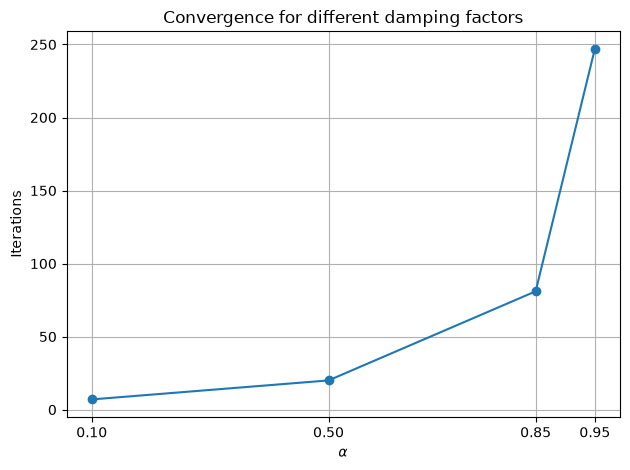

In [170]:
plt.plot(
    sensitivity_results["alpha"],
    sensitivity_results["iterations"],
    marker="o"
)

plt.xlabel(r"$\alpha$")
plt.ylabel("Iterations")
plt.title("Convergence for different damping factors")
plt.xticks(sensitivity_results["alpha"])
plt.grid(True)
plt.tight_layout()
plt.show()

The number of iterations grows rapidly as $\alpha$ approaches one. This behavior is consistent with the slower contraction of the PageRank iteration for larger damping factors.